In [4]:
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

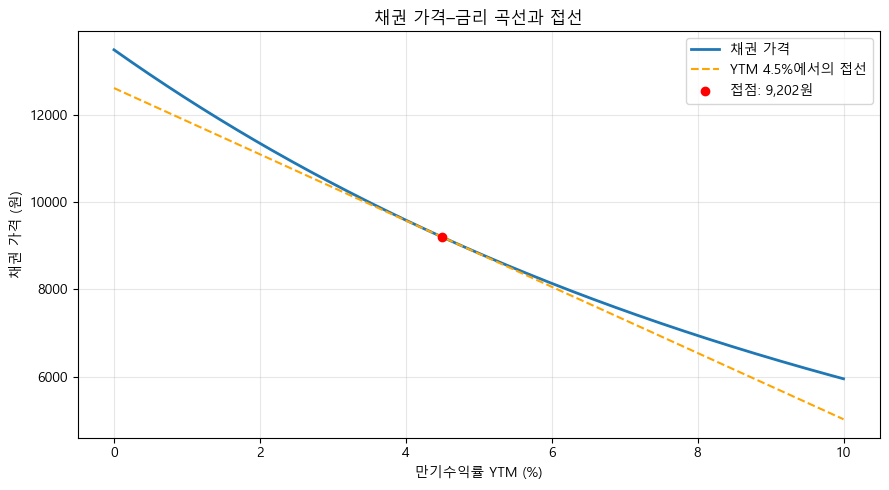

접점의 채권가격: 9,201.81원
기울기 dP/dy: -76,008.11


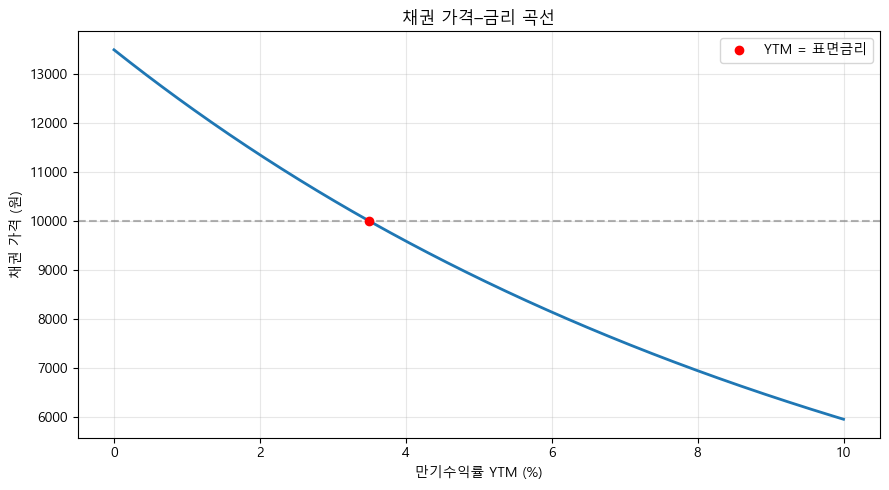

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def bond_price(face, coupon_rate, maturity, ytm, frequency=2):
    """
    face        : 액면가
    coupon_rate : 연 표면금리 (3.5% → 0.035)
    maturity    : 잔존만기(년)
    ytm         : 연 만기수익률
    frequency   : 연간 이자 지급 횟수
    """
    n = int(round(maturity * frequency))
    coupon = face * coupon_rate / frequency

    ytm = np.asarray(ytm, dtype=float)
    period_rate = ytm / frequency

    with np.errstate(divide="ignore", invalid="ignore"):
        price = (
            coupon * (1 - (1 + period_rate) ** (-n)) / period_rate
            + face * (1 + period_rate) ** (-n)
        )

    # 금리가 정확히 0%인 경우
    return np.where(
        np.isclose(period_rate, 0),
        face + coupon * n,
        price
    )
def bond_price_derivative(
    face, coupon_rate, maturity, ytm, frequency=2
):
    """YTM에 대한 채권가격의 1차 미분값"""
    n = int(round(maturity * frequency))
    coupon = face * coupon_rate / frequency

    periods = np.arange(1, n + 1)
    cashflows = np.full(n, coupon)
    cashflows[-1] += face

    period_rate = ytm / frequency

    derivative = -np.sum(
        periods * cashflows
        / (
            frequency
            * (1 + period_rate) ** (periods + 1)
        )
    )

    return derivative


# 접선을 그을 YTM
ytm_point = 0.045  # 4.5%

# 해당 지점의 가격과 기울기
price_point = float(
    bond_price(
        face,
        coupon_rate,
        maturity,
        ytm_point,
        frequency
    )
)

slope = bond_price_derivative(
    face,
    coupon_rate,
    maturity,
    ytm_point,
    frequency
)

# 접선
tangent_prices = price_point + slope * (ytm - ytm_point)

plt.figure(figsize=(9, 5))

plt.plot(
    ytm * 100,
    prices,
    linewidth=2,
    label="채권 가격"
)

plt.plot(
    ytm * 100,
    tangent_prices,
    linestyle="--",
    color="orange",
    label=f"YTM {ytm_point * 100:.1f}%에서의 접선"
)

plt.scatter(
    ytm_point * 100,
    price_point,
    color="red",
    zorder=3,
    label=f"접점: {price_point:,.0f}원"
)

plt.xlabel("만기수익률 YTM (%)")
plt.ylabel("채권 가격 (원)")
plt.title("채권 가격–금리 곡선과 접선")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"접점의 채권가격: {price_point:,.2f}원")
print(f"기울기 dP/dy: {slope:,.2f}")

# 채권 조건
face = 10_000
coupon_rate = 0.035
maturity = 10
frequency = 2

# YTM 0~10%
ytm = np.linspace(0, 0.10, 500)
prices = bond_price(
    face,
    coupon_rate,
    maturity,
    ytm,
    frequency
)

plt.figure(figsize=(9, 5))
plt.plot(ytm * 100, prices, linewidth=2)

# YTM = 표면금리일 때 액면가
plt.scatter(
    [coupon_rate * 100],
    [face],
    color="red",
    zorder=3,
    label="YTM = 표면금리"
)

plt.axhline(face, color="gray", linestyle="--", alpha=0.6)
plt.xlabel("만기수익률 YTM (%)")
plt.ylabel("채권 가격 (원)")
plt.title("채권 가격–금리 곡선")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()